<h1> Extracting very coarse ERA5 data and building super simple ML </h1>

Developing towards the Anemoi Keisler 2022 (or at least practicing)

We'll load the coarsest 64 x 32 ERA5 data from the WeatherBench public Google Cloud bucket

Requires at least the packages:
- xarray
- gcsfs
- fsspec
- zarr 
- numpy
- torch
- matplotlib

In [21]:
import numpy as np
import torch 
import torch.nn as nn

# The following are for a ChatGPT-generated message-passing GNN:
from torch_geometric.data import Data
from torch_geometric.utils import dense_to_sparse
from torch_geometric.nn import MessagePassing
import torch.nn.functional as F

import matplotlib.pyplot as plt
import xarray as xr


In [22]:

# This automatically uses gcsfs under the hood
ds = xr.open_zarr(
    #'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr',
    'gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr',
    consolidated=True
)

ds


<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 512B ...
  * time                                              (time) datetime64[ns] 748kB ...
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

In [23]:
# Our first dataset will be simply the 500 hPa geopotential

geopotential_500=ds['geopotential'].isel(level=7)

latitudes=ds['latitude']
longitudes=ds['longitude']

geopotential_500, latitudes, longitudes


(<xarray.DataArray 'geopotential' (time: 93544, longitude: 64, latitude: 32)> Size: 766MB
 dask.array<getitem, shape=(93544, 64, 32), dtype=float32, chunksize=(100, 64, 32), chunktype=numpy.ndarray>
 Coordinates:
   * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
     level      int64 8B 500
   * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
   * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
 Attributes:
     long_name:      Geopotential
     short_name:     z
     standard_name:  geopotential
     units:          m**2 s**-2,
 <xarray.DataArray 'latitude' (latitude: 32)> Size: 256B
 array([-87.1875, -81.5625, -75.9375, -70.3125, -64.6875, -59.0625, -53.4375,
        -47.8125, -42.1875, -36.5625, -30.9375, -25.3125, -19.6875, -14.0625,
         -8.4375,  -2.8125,   2.8125,   8.4375,  14.0625,  19.6875,  25.3125,
         30.9375,  36.5625,  42.1875,  47.8125,  53.4375,  59.0625,  64.6875,
         70.3125,

In [24]:
geopotential_500

<xarray.DataArray 'geopotential' (time: 93544, longitude: 64, latitude: 32)> Size: 766MB
dask.array<getitem, shape=(93544, 64, 32), dtype=float32, chunksize=(100, 64, 32), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
    level      int64 8B 500
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
Attributes:
    long_name:      Geopotential
    short_name:     z
    standard_name:  geopotential
    units:          m**2 s**-2

In [25]:
# Let's "hack" even more and take just the last 100 time steps

#geopotential_500=geopotential_500.isel(time=slice(-100, None))


# Improving to 1000 time steps:
geopotential_500=geopotential_500.isel(time=slice(-1000, None)).load()  # Had to include load, otherwise it's caching the old one


# And let's convert to a torch tensor for future use
geo500_data=torch.from_numpy(geopotential_500.values)
geo500_data.shape

torch.Size([1000, 64, 32])

In [26]:
import numpy as np

class Graph:
    def __init__(self, width, height, latitudes=None, longitudes=None, data=None):
        self.width = width
        self.height = height

        if latitudes is None:
            latitudes = np.linspace(90, -90, height)
        if longitudes is None:
            longitudes = np.linspace(0, 360, width, endpoint=False)

        self.latitudes = latitudes
        self.longitudes = longitudes

        # Coordinates and graph structure
        self.coords = np.zeros((width, height, 2), dtype=float)        # (lat, lon)
        self.neighbors = np.zeros((width, height, 4, 2), dtype=int)    # 4 neighbor (i,j) pairs
        
        # Validate and assign data
        if data is not None:
            if data.shape[1:] != (width, height):
                raise ValueError(f"Data shape must be (n_time, {width}, {height}), but got {data.shape}")
            self.data = data
        else:
            self.data = None

        self._build_graph()

    def _build_graph(self):
        for i in range(self.width):
            for j in range(self.height):
                self.coords[i, j] = (self.latitudes[j], self.longitudes[i])

                # 4-neighborhood with periodic boundary conditions
                neighbor_coords = [
                    ((i - 1) % self.width, j),    # left
                    ((i + 1) % self.width, j),    # right
                    (i, (j - 1) % self.height),   # up
                    (i, (j + 1) % self.height)    # down
                ]

                self.neighbors[i, j] = neighbor_coords

    def flat_index(self, i, j):
        return i * self.height + j

    def get_adjacency_matrix(self):
        N = self.width * self.height
        adj = np.zeros((N, N), dtype=int)

        for i in range(self.width):
            for j in range(self.height):
                node_id = self.flat_index(i, j)
                for ni, nj in self.neighbors[i, j]:
                    neighbor_id = self.flat_index(ni, nj)
                    adj[node_id, neighbor_id] = 1
        return adj


In [27]:
graph = Graph(64, 32, latitudes=latitudes, longitudes=longitudes, data=geo500_data)

In [28]:


example_index=[12,15]
print("Lat/Lon at example index:", graph.coords[example_index[0],example_index[1]])      
print("Neighbors at example index:", graph.neighbors[example_index[0],example_index[1]])
neighbors_example=graph.neighbors[example_index[0],example_index[1]]   
print("Coordinates of neighbors: ", graph.coords[neighbors_example[0][0],neighbors_example[0][1]],
      graph.coords[neighbors_example[1][0],neighbors_example[1][1]],
      graph.coords[neighbors_example[2][0],neighbors_example[2][1]],
      graph.coords[neighbors_example[3][0],neighbors_example[3][1]])


Lat/Lon at example index: [-2.8125 67.5   ]
Neighbors at example index: [[11 15]
 [13 15]
 [12 14]
 [12 16]]
Coordinates of neighbors:  [-2.8125 61.875 ] [-2.8125 73.125 ] [-8.4375 67.5   ] [ 2.8125 67.5   ]


In [29]:
# Sanity check that the graph gives the right coordinates for extracting data:

example_time=0
example_index=[2,20]

graph_coords_example=[graph.coords[example_index[0],example_index[1]]]

print("Our example lat, lon coordinates are: ", graph_coords_example)

data_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]]

print("Data from our torch tensor: ", data_from_torch_tensor)

graph_coords_example=graph.coords[example_index[0],example_index[1]]


data_from_original_xarray=geopotential_500.sel(
          time=geopotential_500.time[example_time],
          latitude=graph_coords_example[0],
          longitude=graph_coords_example[1]#,
          #method='nearest'   # optional for float matching
      ).values

print("Data from original xarray dataset with graph coords:",data_from_original_xarray)

difference=data_from_torch_tensor-data_from_original_xarray

print("This difference should be zero up to rounding error: ", difference)


Our example lat, lon coordinates are:  [array([25.3125, 11.25  ])]
Data from our torch tensor:  tensor(57694.7695)
Data from original xarray dataset with graph coords: 57694.77
This difference should be zero up to rounding error:  tensor(0.)


/tmp/ipykernel_2245010/2533668588.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  difference=data_from_torch_tensor-data_from_original_xarray


Pre-processing for GNN

In [30]:
# Normalize geopotential data
geo_mean = geo500_data.mean()
geo_std = geo500_data.std()
geo_norm = (geo500_data - geo_mean) / geo_std

# And redefine the graph with normalized values:
graph = Graph(64, 32, latitudes=latitudes, longitudes=longitudes, data=geo_norm)

In [31]:
graph.data.shape

torch.Size([1000, 64, 32])

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
import numpy as np

# 1. Prepare edge_index from your graph's adjacency matrix
adj = graph.get_adjacency_matrix()  # shape [N, N]
edge_index = np.array(np.nonzero(adj))  # shape [2, num_edges]
edge_index = torch.tensor(edge_index, dtype=torch.long)


In [33]:
for i in range(2):
    print("Here: ", i)

Here:  0
Here:  1


Step 0, Loss: 0.930802
Step 1, Loss: 0.774377
Step 2, Loss: 0.637814
Step 3, Loss: 0.503849
Step 4, Loss: 0.396319
Step 5, Loss: 0.295399
Step 6, Loss: 0.215186
Step 7, Loss: 0.146468
Step 8, Loss: 0.098989
Step 9, Loss: 0.060947
Step 10, Loss: 0.039871
Step 11, Loss: 0.026448
Step 12, Loss: 0.020100
Step 13, Loss: 0.020027
Step 14, Loss: 0.022482
Step 15, Loss: 0.032533
Step 16, Loss: 0.040741
Step 17, Loss: 0.053140
Step 18, Loss: 0.057828
Step 19, Loss: 0.064056
Step 20, Loss: 0.061594
Step 21, Loss: 0.060348
Step 22, Loss: 0.052281
Step 23, Loss: 0.047707
Step 24, Loss: 0.038395
Step 25, Loss: 0.032606
Step 26, Loss: 0.024529
Step 27, Loss: 0.020744
Step 28, Loss: 0.016558
Step 29, Loss: 0.014236
Step 30, Loss: 0.011856
Step 31, Loss: 0.011230
Step 32, Loss: 0.011815
Step 33, Loss: 0.012710
Step 34, Loss: 0.014012
Step 35, Loss: 0.015586
Step 36, Loss: 0.018793
Step 37, Loss: 0.021671
Step 38, Loss: 0.024524
Step 39, Loss: 0.026081
Step 40, Loss: 0.028512
Step 41, Loss: 0.029143
St

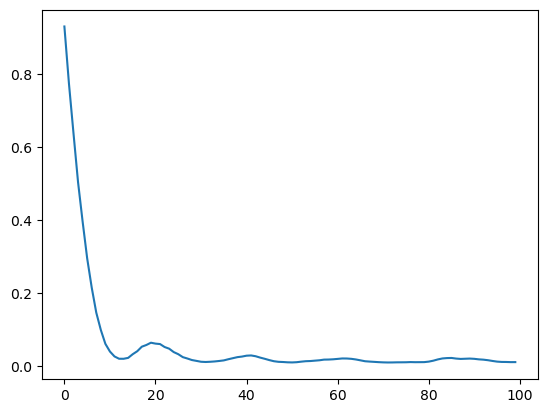

In [34]:

# 2. Define a multi-layer message-passing GNN
class GNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='mean')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return self.lin(x_j)

class MultiLayerGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(GNNLayer(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.layers.append(GNNLayer(hidden_channels, hidden_channels))
        self.layers.append(GNNLayer(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
        x = self.layers[-1](x, edge_index)
        return x

# 3. Instantiate model, optimizer, and loss
# Svante comment: num_layers=2 should create one GNN layer too as read from the code
# or two to be exact, one in and one out:
model = MultiLayerGNN(in_channels=1, hidden_channels=32, out_channels=1, num_layers=2)


optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()


loss_list = []
num_steps = 100  
for t in range(num_steps):
    # Use graph.data for input and target
    x = graph.data[t].reshape(-1, 1).float()        # shape [2048, 1]
    y_true = graph.data[t+1].reshape(-1, 1).float() # shape [2048, 1]
    out = model(x, edge_index)
    loss = loss_fn(out, y_true)
    loss_list.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t == 70:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.001
    print(f"Step {t}, Loss: {loss.item():.6f}")
plt.plot(loss_list)
plt.show()

In [35]:
model.layers[0]

GNNLayer()

In [36]:
# Convert geo_mean and geo_std to scalars for numpy operations
#geo_mean_val = geo_mean.item() if hasattr(geo_mean, "item") else float(geo_mean)
#geo_std_val = geo_std.item() if hasattr(geo_std, "item") else float(geo_std)
# Choose a time step to predict (e.g., t = 101)
t_pred = 101
x_input = geo_norm[t_pred-1].reshape(-1, 1).float()

# Model prediction
model.eval()
with torch.no_grad():
    y_pred = model(x_input, edge_index).cpu().numpy().reshape(64, 32)
y_true = geo_norm[t_pred].cpu().numpy().reshape(64, 32)

# Denormalize
y_pred_denorm = y_pred * geo_std_val + geo_mean_val
y_true_denorm = y_true * geo_std_val + geo_mean_val
diff = y_pred_denorm - y_true_denorm

NameError: name 'geo_std_val' is not defined

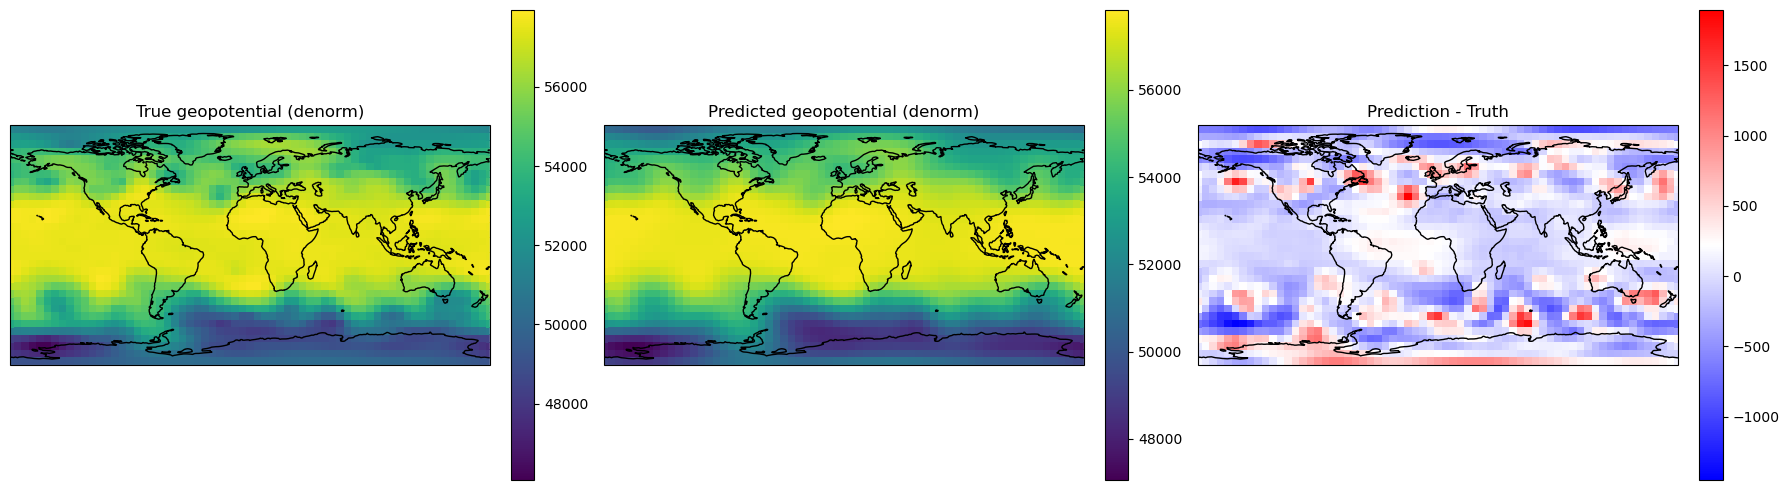

In [81]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Prepare longitude and latitude meshgrid for pcolormesh
lons = graph.longitudes
lats = graph.latitudes
lon2d, lat2d = np.meshgrid(lons, lats, indexing='ij')  # shape (64, 32)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

# True field
pcm0 = axs[0].pcolormesh(lon2d, lat2d, y_true_denorm, shading='auto', cmap='viridis')
axs[0].set_title('True geopotential (denorm)')
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')
axs[0].coastlines()
plt.colorbar(pcm0, ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)

# Predicted field
pcm1 = axs[1].pcolormesh(lon2d, lat2d, y_pred_denorm, shading='auto', cmap='viridis')
axs[1].set_title('Predicted geopotential (denorm)')
axs[1].set_xlabel('Longitude')
axs[1].set_ylabel('Latitude')
axs[1].coastlines()
plt.colorbar(pcm1, ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)

# Difference
pcm2 = axs[2].pcolormesh(lon2d, lat2d, diff, shading='auto', cmap='bwr')
axs[2].set_title('Prediction - Truth')
axs[2].set_xlabel('Longitude')
axs[2].set_ylabel('Latitude')
axs[2].coastlines()
plt.colorbar(pcm2, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()     

In [63]:
import numpy as np

print(np.sqrt(np.mean(diff**2)))

print(torch.sqrt(torch.mean  (( geo500_data[101,:,:]-geo500_data[100,:,:])**2 )))

407.8785
tensor(236.6555)


Let's start building our ML model by using as input/predictor the geo500_data at time t at each point plus its neighbors.

Then we predict geo500_data at t+1.

In [37]:

# Original tensor
geo = geo500_data  # shape (100, 64, 32)

# Inputs: t from 0 to 98 → use geo[t] for prediction of geo[t+1]
x_raw = geo[:-1]  # shape (99, 64, 32)
y = geo[1:]       # shape (99, 64, 32)

# Prepare 5 input channels per point
x_center = x_raw                              # (99, 64, 32)
x_left   = torch.roll(x_raw, shifts=+1, dims=2)  # left neighbor (i-1)
x_right  = torch.roll(x_raw, shifts=-1, dims=2)  # right neighbor (i+1)
x_up     = torch.roll(x_raw, shifts=-1, dims=1)  # up neighbor (j-1)
x_down   = torch.roll(x_raw, shifts=+1, dims=1)  # down neighbor (j+1)

# Stack as new feature dimension
x = torch.stack([x_center, x_left, x_right, x_up, x_down], dim=-1)  # shape: (99, 64, 32, 5)


In [38]:
class Graph:
    def __init__(self, d1, d2, edges, node_values=None, edge_attributes=None):
        self.d1 = int(d1)
        self.d2 = int(d2)
        self.num_nodes = self.d1 * self.d2
        self.edges = edges  # list of (src, dst)
        self.edge_attributes = edge_attributes
        self.node_values = None
        if node_values is not None:
            self.set_node_values(node_values)

    @staticmethod
    def node_id(i, j, d2):
        return i * d2 + j

    def set_node_values(self, node_values):
        v = node_values
        # Accept either (T, d1, d2) or (T, num_nodes)
        if v.dim() == 3:
            if v.shape[1:] != (self.d1, self.d2):
                raise ValueError(f"Expected node_values shape (T, {self.d1}, {self.d2}), got {tuple(v.shape)}")
            v = v.reshape(v.shape[0], self.num_nodes)
        elif v.dim() == 2:
            if v.shape[1] != self.num_nodes:
                raise ValueError(f"Expected node_values shape (T, {self.num_nodes}), got {tuple(v.shape)}")
        else:
            raise ValueError("node_values must have shape (T, d1, d2) or (T, num_nodes)")
        self.node_values = v

    def __repr__(self):
        t_steps = None if self.node_values is None else int(self.node_values.shape[0])
        return (
            f"Graph(d1={self.d1}, d2={self.d2}, num_nodes={self.num_nodes}, "
            f"num_edges={len(self.edges)}, T={t_steps}, has_edge_attributes={self.edge_attributes is not None})"
        )


def build_grid_graph_from_snapshot(snapshot_2d, node_values=None, edge_attributes=None):
    s = snapshot_2d
    # Handle a leading singleton spatial dimension, e.g. (1, d1, d2)
    if s.dim() == 3 and s.shape[0] == 1:
        s = s[0]
    if s.dim() != 2:
        raise ValueError(f"Expected 2D snapshot or (1, d1, d2), got {tuple(s.shape)}")

    d1, d2 = s.shape
    edges = []

    # Periodic (roll-like) neighborhood: left/right in j, up/down in i
    for i in range(d1):
        for j in range(d2):
            src = Graph.node_id(i, j, d2)
            left = Graph.node_id(i, (j - 1) % d2, d2)
            right = Graph.node_id(i, (j + 1) % d2, d2)
            up = Graph.node_id((i - 1) % d1, j, d2)
            down = Graph.node_id((i + 1) % d1, j, d2)
            edges.extend([(src, left), (src, right), (src, up), (src, down)])

    return Graph(d1=d1, d2=d2, edges=edges, node_values=node_values, edge_attributes=edge_attributes)


# Build graph from one spatial snapshot
grid_graph = build_grid_graph_from_snapshot(geo[0])
print(grid_graph)

# Optional: attach time-dependent scalar node values (T, d1, d2)
grid_graph_with_values = build_grid_graph_from_snapshot(geo[0], node_values=geo)
print(grid_graph_with_values)
print("node_values shape (flattened):", tuple(grid_graph_with_values.node_values.shape))

Graph(d1=64, d2=32, num_nodes=2048, num_edges=8192, T=None, has_edge_attributes=False)
Graph(d1=64, d2=32, num_nodes=2048, num_edges=8192, T=1000, has_edge_attributes=False)
node_values shape (flattened): (1000, 2048)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


def build_edge_index(graph, add_self_loops=False):
    edges = list(graph.edges)
    if add_self_loops:
        edges.extend((n, n) for n in range(graph.num_nodes))

    src = torch.tensor([e[0] for e in edges], dtype=torch.long)
    dst = torch.tensor([e[1] for e in edges], dtype=torch.long)
    return torch.stack([src, dst], dim=0)


class SimpleGNN(nn.Module):
    def __init__(self, message_passing_steps=2, hidden_width=256):
        super().__init__()
        self.message_passing_steps = int(message_passing_steps)

        # Message from sender->receiver based on (h_src, h_dst)
        self.message_mlp = nn.Sequential(
            nn.Linear(2, hidden_width),
            nn.ReLU(),
            nn.Linear(hidden_width, 1),
        )

        # Update each node using current state + aggregated neighbor message
        self.update_mlp = nn.Sequential(
            nn.Linear(2, hidden_width),
            nn.ReLU(),
            nn.Linear(hidden_width, 1),
        )

    def forward(self, node_values_t, edge_index):
        # node_values_t: (num_nodes,) scalar value per node at one timestep
        h = node_values_t.reshape(-1, 1)
        src, dst = edge_index[0], edge_index[1]

        for _ in range(self.message_passing_steps):
            message_inputs = torch.cat([h[src], h[dst]], dim=1)  # (num_edges, 2)
            messages = self.message_mlp(message_inputs)          # (num_edges, 1)

            # Mean aggregation of incoming messages for each destination node
            agg = torch.zeros_like(h)
            agg.index_add_(0, dst, messages)

            deg = torch.zeros_like(h)
            deg.index_add_(0, dst, torch.ones_like(messages))
            agg = agg / deg.clamp_min(1.0)

            update_inputs = torch.cat([h, agg], dim=1)
            h = self.update_mlp(update_inputs)

        return h.squeeze(-1)


# Build graph for geo[0, :, :] and attach full time series as optional node values
train_graph = build_grid_graph_from_snapshot(geo[0], node_values=geo)

# About self-loops:
# Not strictly necessary here because the update already uses each node's own h directly.
# Still, we keep this as an option and set it True by default (common in GNN practice).
add_self_loops = True
edge_index = build_edge_index(train_graph, add_self_loops=add_self_loops)

# Data as (T, num_nodes), predict t+1 from t
node_values = train_graph.node_values.float()
inputs = node_values[:-1]
targets = node_values[1:]

# Time-based split: first 80% train, last 20% test
num_samples = inputs.shape[0]
split_idx = int(0.8 * num_samples)
train_x, test_x = inputs[:split_idx], inputs[split_idx:]
train_y, test_y = targets[:split_idx], targets[split_idx:]


def predict_sequence(model, x_seq, edge_index):
    preds = []
    for t in range(x_seq.shape[0]):
        preds.append(model(x_seq[t], edge_index))
    return torch.stack(preds, dim=0)


model = SimpleGNN(message_passing_steps=2, hidden_width=3)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_losses = []

epochs = 250
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    train_pred = predict_sequence(model, train_x, edge_index)
    train_loss = loss_fn(train_pred, train_y)
    train_losses.append(train_loss.item())

    train_loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss.item():.6f}")


model.eval()
with torch.no_grad():
    final_train_pred = predict_sequence(model, train_x, edge_index)
    final_test_pred = predict_sequence(model, test_x, edge_index)

    final_train_loss = loss_fn(final_train_pred, train_y).item()
    final_test_loss = loss_fn(final_test_pred, test_y).item()

print("Final train loss:", final_train_loss)
print("Final test loss:", final_test_loss)
print("Train/Test samples:", train_x.shape[0], test_x.shape[0])
print("Self loops enabled:", add_self_loops)

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("SimpleGNN training loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Epoch   0 | train_loss=1973164928.000000


In [61]:
print("Is CUDA available?", torch.cuda.is_available())

model.eval()
device = next(model.parameters()).device

x0 = test_x[0].to(device)        # from the GNN cell, shape (num_nodes,)
y0 = test_y[0].to(device)
ei = edge_index.to(device)

with torch.no_grad():
    prediction1 = model(x0, ei)

print("prediction shape:", prediction1.shape, "target shape:", y0.shape)
print("mean abs error:", (prediction1 - y0).abs().mean().item())

# Baseline benchmark: mean absolute difference between test sample 1 and test sample 0
baseline_mae = (test_y[1] - test_y[0]).abs().mean().item()
print("Baseline mean abs(test[1] - test[0]):", baseline_mae)

Is CUDA available? True
prediction shape: torch.Size([2048]) target shape: torch.Size([2048])
mean abs error: 53922.88671875
Baseline mean abs(test[1] - test[0]): 169.38485717773438


In [29]:
print("x_center mean: ", torch.mean(x_center))
print("x_left mean: ", torch.mean(x_left))
print("x_right mean: ", torch.mean(x_right))
print("x_up mean: ", torch.mean(x_up))
print("x_down mean: ", torch.mean(x_down))

print(x_center[0,0,0])
print(x_left[0,0,1])
print(x_right[0,0,-1])
print(x_up[0,-1,0])
print(x_down[0,1,0])




x_center mean:  tensor(54292.7227)
x_left mean:  tensor(54292.7266)
x_right mean:  tensor(54292.7227)
x_up mean:  tensor(54292.7344)
x_down mean:  tensor(54292.7305)
tensor(48168.3711)
tensor(48168.3711)
tensor(48168.3711)
tensor(48168.3711)
tensor(48168.3711)


In [37]:
print(999*64*32)
print(x_center.flatten().shape)


2045952
torch.Size([2045952])


In [16]:
# Let's again run a sanity check to make sure the data is correct

example_time=0
example_index=[2,20]

x_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]]
print(x_from_torch_tensor,x_raw[example_time,example_index[0],example_index[1]])
x_left_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]-1]
print(x_left_from_torch_tensor,x_left[example_time,example_index[0],example_index[1]])
x_right_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]+1]
print(x_right_from_torch_tensor,x_right[example_time,example_index[0],example_index[1]])
x_up_from_torch_tensor=geo500_data[example_time,example_index[0]+1,example_index[1]]
print(x_up_from_torch_tensor,x_up[example_time,example_index[0],example_index[1]])
x_down_from_torch_tensor=geo500_data[example_time,example_index[0]-1,example_index[1]]
print(x_down_from_torch_tensor,x_down[example_time,example_index[0],example_index[1]])

# And create parameters for reshaping the tensors to (samples, features)

n_times=geo500_data.shape[0]
n_lat=64
n_lon=32
n_features=5

num_samples = (n_times-1) * n_lat * n_lon

print(x.shape, num_samples)

x_flat = x.reshape(num_samples, n_features)
y_flat = y.reshape(num_samples)

print(x_flat.shape, y_flat.shape)

# Checking also that x_up has the same values as x_raw (as it should only be a shifted array/tensor)
print(torch.min(x_up),torch.max(x_up),torch.mean(x_up),torch.std(x_up))
print(torch.min(x_raw),torch.max(x_raw),torch.mean(x_raw),torch.std(x_raw))

tensor(57694.7695) tensor(57694.7695)
tensor(58061.6680) tensor(58061.6680)
tensor(56803.2617) tensor(56803.2617)
tensor(57785.0703) tensor(57785.0703)
tensor(57569.1250) tensor(57569.1250)
torch.Size([999, 64, 32, 5]) 2045952
torch.Size([2045952, 5]) torch.Size([2045952])
tensor(43248.1992) tensor(59019.7930) tensor(54292.7344) tensor(3397.1411)
tensor(43248.1992) tensor(59019.7930) tensor(54292.7227) tensor(3397.1411)


Now we get to the first ML forecast. This is just puked out from ChatGPT, no testing done yet.

In [40]:
from sklearn.model_selection import train_test_split

# Convert to float32 if needed
x_flat = x_flat.float()
y_flat = y_flat.float()

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x_flat, y_flat, test_size=0.2, random_state=42)


In [41]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # to match shape (N,) with y


torch.Size([1636761, 5])

In [42]:
model = SimpleMLP()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Convert to device if needed (e.g., CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model.to(device)
x_train, x_test = x_train.to(device), x_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)


x_flat.shape, x_test.device

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

print(x_train.device, y_train.device, model.net[0].weight.device)

#print(torch.cuda.is_available())

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#x_train = x_train.to(device)
#y_train = y_train.to(device)
#x_test = x_test.to(device)
#y_test = y_test.to(device)
#model.to(device)

# Training loop
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

    print(f"Epoch {epoch:02d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")



cuda:0 cuda:0 cuda:0
Epoch 00 | Train Loss: 2763142912.0000 | Test Loss: 2693875456.0000
Epoch 01 | Train Loss: 2693807872.0000 | Test Loss: 2628750080.0000
Epoch 02 | Train Loss: 2628689920.0000 | Test Loss: 2566027520.0000
Epoch 03 | Train Loss: 2565970432.0000 | Test Loss: 2503461376.0000
Epoch 04 | Train Loss: 2503406848.0000 | Test Loss: 2440997120.0000
Epoch 05 | Train Loss: 2440945152.0000 | Test Loss: 2378615552.0000
Epoch 06 | Train Loss: 2378566656.0000 | Test Loss: 2316288512.0000
Epoch 07 | Train Loss: 2316242176.0000 | Test Loss: 2253997312.0000
Epoch 08 | Train Loss: 2253953792.0000 | Test Loss: 2191745792.0000
Epoch 09 | Train Loss: 2191704576.0000 | Test Loss: 2129574400.0000
Epoch 10 | Train Loss: 2129536000.0000 | Test Loss: 2068214272.0000
Epoch 11 | Train Loss: 2068178944.0000 | Test Loss: 2007608320.0000
Epoch 12 | Train Loss: 2007575040.0000 | Test Loss: 1946997760.0000
Epoch 13 | Train Loss: 1946966656.0000 | Test Loss: 1886308992.0000
Epoch 14 | Train Loss: 1886

In [48]:
print("Average x: ", torch.mean(x_test))
print(model.forward(x_test[0,:]))
print(y_test[0])

print(y_test[0]-model.forward(x_test[0,:]).item())

Average x:  tensor(54293.4375, device='cuda:0')
tensor(49414.4453, device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor(49739.2617, device='cuda:0')
tensor(324.8164, device='cuda:0')


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Define model (no fitting here yet)
class SimpleRandomForest:
    def __init__(self, n_estimators=100, max_depth=10):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )

    def fit(self, x, y):
        self.model.fit(x, y)

    def predict(self, x):
        return self.model.predict(x)


In [21]:
# x_flat: torch tensor of shape (N, 5)
# y_flat: torch tensor of shape (N,)

x_np = x_flat.cpu().numpy()
y_np = y_flat.cpu().numpy()

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x_train, x_test, y_train, y_test = train_test_split(x_np, y_np, test_size=0.2, random_state=42)

rf_model = SimpleRandomForest(n_estimators=100, max_depth=10)
rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)
mse_rf = mean_squared_error(y_test, y_pred)
print(f"Random Forest MSE: {mse_rf:.4f}")


Random Forest MSE: 35444.7104


In [22]:

print(np.sqrt(torch.mean((x_raw-y)**2)))

print(x_train.shape)

plt.scatter(model(x[0,:]).detach().numpy(),y[0].detach().numpy())

x_sample_example=model(x[0,:]).detach().numpy()
y_sample_example=y[0].detach().numpy()

#print(x_sample_example.shape,y_sample_example.shape)
print(np.sqrt(np.mean((x_sample_example-y_sample_example)**2)))

print(torch.sqrt(loss))



tensor(228.8092)
(1636761, 5)


/tmp/ipykernel_220561/563340539.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(np.sqrt(torch.mean((x_raw-y)**2)))


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

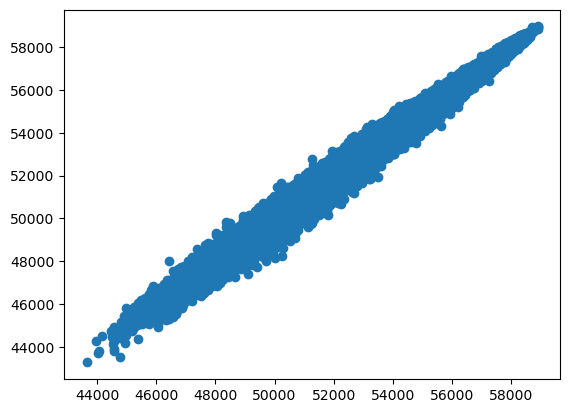

188.26765620797755


In [ ]:
plt.scatter(y_pred,y_test)
plt.show()

print(np.sqrt(np.mean((y_pred-y_test)**2)))

In [ ]:
n_times_test=20
y_pred_grid = y_pred.reshape(n_times_test, n_lat, n_lon)

ValueError: cannot reshape array of size 40551 into shape (20,64,32)

In [126]:
n_times, n_lat, n_lon, n_features = x.shape
split_idx = int(n_times * 0.8)  # e.g. 79 if n_times=99

# Split in time
x_train = x[:split_idx]    # (79, 64, 32, 5)
x_test  = x[split_idx:]    # (20, 64, 32, 5)
y_train = y[:split_idx]    # (79, 64, 32)
y_test  = y[split_idx:]    # (20, 64, 32)

# Flatten space for ML
x_train_flat = x_train.reshape(-1, n_features)  # (79*64*32, 5)
x_test_flat  = x_test.reshape(-1, n_features)   # (20*64*32, 5)
y_train_flat = y_train.reshape(-1)
y_test_flat  = y_test.reshape(-1)


# Normalize, start with calculating means:
normalizer_mean=torch.mean(x)
normalizer_std=torch.std(x)
x_train_flat = (x_train_flat - normalizer_mean) / normalizer_std
x_test_flat = (x_test_flat - normalizer_mean) / normalizer_std
y_train_flat = (y_train_flat - normalizer_mean) / normalizer_std
y_test_flat = (y_test_flat - normalizer_mean) / normalizer_std

# Also convert to numpu to prevent future problems:
normalizer_mean=normalizer_mean.detach().numpy()
normalizer_std=normalizer_std.detach().numpy()
x_train_flat=x_train_flat.detach().numpy()
x_test_flat=x_test_flat.detach().numpy()
y_train_flat=y_train_flat.detach().numpy()
y_test_flat=y_test_flat.detach().numpy()


In [127]:
rf_model = SimpleRandomForest(n_estimators=200, max_depth=10)
rf_model.fit(x_train_flat, y_train_flat)

y_pred_flat = rf_model.predict(x_test_flat)






mse_rf = mean_squared_error(y_test_flat, y_pred_flat)
print(f"Random Forest MSE (time-split): {mse_rf:.4f}")

# Reverse normalization:
y_pred = y_pred * normalizer_std + normalizer_mean
y_pred_flat = y_pred_flat * normalizer_std + normalizer_mean


Random Forest MSE (time-split): 0.0036


In [110]:
n_test_time = x_test.shape[0]
y_pred_grid = y_pred_flat.reshape(n_test_time, n_lat, n_lon)


In [128]:

print(np.sqrt(np.mean((y_pred_grid-y_test.detach().numpy())**2)))

# Check persistence benchmark
y_test_benchmarker_train=y_test.detach().numpy()[:-1,:,:]
y_test_benchmarker_persistence=y_test.detach().numpy()[1:,:,:]

print(np.sqrt(np.mean((y_test_benchmarker_train-y_test_benchmarker_persistence)**2)))


204.75688591214538
233.28517


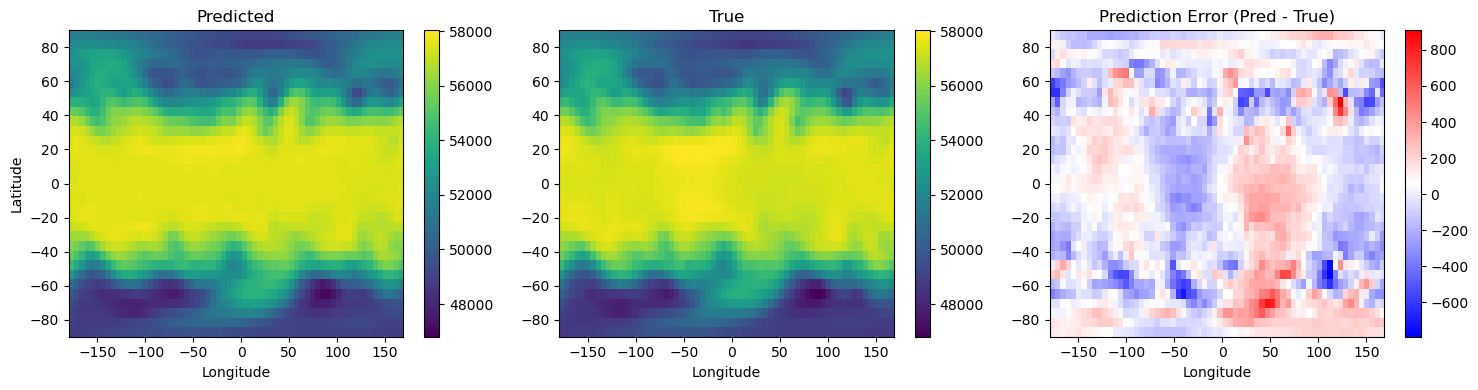

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# Your latitude and longitude arrays from the dataset
latitudes = np.linspace(-90, 90, 64)           # or from ds['latitude'].values
longitudes = np.linspace(0, 360, 32, endpoint=False)
longitudes = (longitudes + 180) % 360 - 180    # Shift to [-180, 180]

# Create extent for imshow: [xmin, xmax, ymin, ymax]
extent = [longitudes.min(), longitudes.max(), latitudes.min(), latitudes.max()]

# Pick a single time index to plot
t = 10

vmin = min(y_pred_grid[t].min(), y_test[t].min())
vmax = max(y_pred_grid[t].max(), y_test[t].max())

plt.figure(figsize=(15, 4))

# 🔹 Predicted
plt.subplot(1, 3, 1)
plt.imshow(y_pred_grid[t].T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax,
           extent=extent, aspect='auto')
plt.title("Predicted")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()

# 🔹 True
plt.subplot(1, 3, 2)
plt.imshow(y_test[t].T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax,
           extent=extent, aspect='auto')
plt.title("True")
plt.xlabel("Longitude")
plt.colorbar()

# 🔹 Difference
plt.subplot(1, 3, 3)
plt.imshow((y_pred_grid[t] - y_test[t].detach().numpy()).T, origin='lower',
           cmap='bwr', extent=extent, aspect='auto')
plt.title("Prediction Error (Pred - True)")
plt.xlabel("Longitude")
plt.colorbar()

plt.tight_layout()
plt.show()
